<a href="https://colab.research.google.com/github/Tauhid-Topu-007/DEPRESSION-AND-ANXIETY-DETECTION-MODEL-FOR-STUDENTS/blob/main/DDNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DDNet: Depression Detection Network

PART 1: DATA LOADING AND EXPLORATION

Dataset Shape: (2966, 14)
Columns: ['age', 'age_group', 'gender', 'stress_level', 'anxiety_score', 'depression_score', 'combined_mental_health_score', 'risk_category', 'sleep_quality', 'sleep_hours', 'social_support', 'physical_activity_days', 'mental_health_condition', 'source']

Data Types:
age                               int64
age_group                        object
gender                           object
stress_level                     object
anxiety_score                   float64
depression_score                float64
combined_mental_health_score    float64
risk_category                    object
sleep_quality                    object
sleep_hours                     float64
social_support                  float64
physical_activity_days          float64
mental_health_condition          object
source                           object
dtype: object

Missing Values:
age                             0
age_gr

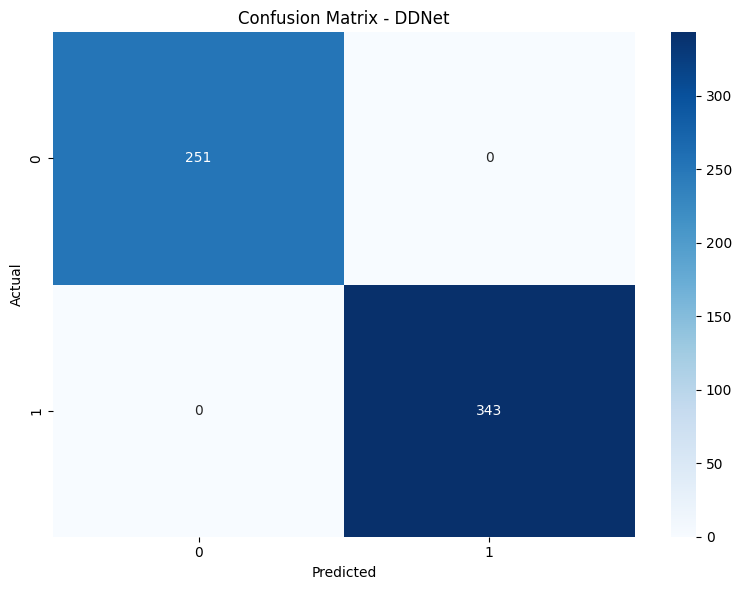

Confusion matrix saved as 'confusion_matrix.png'


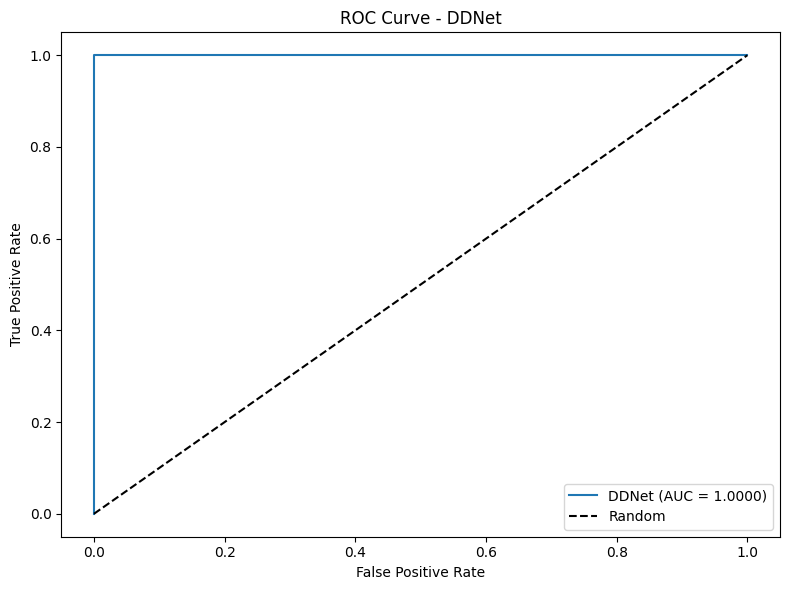

ROC curve saved as 'roc_curve.png'


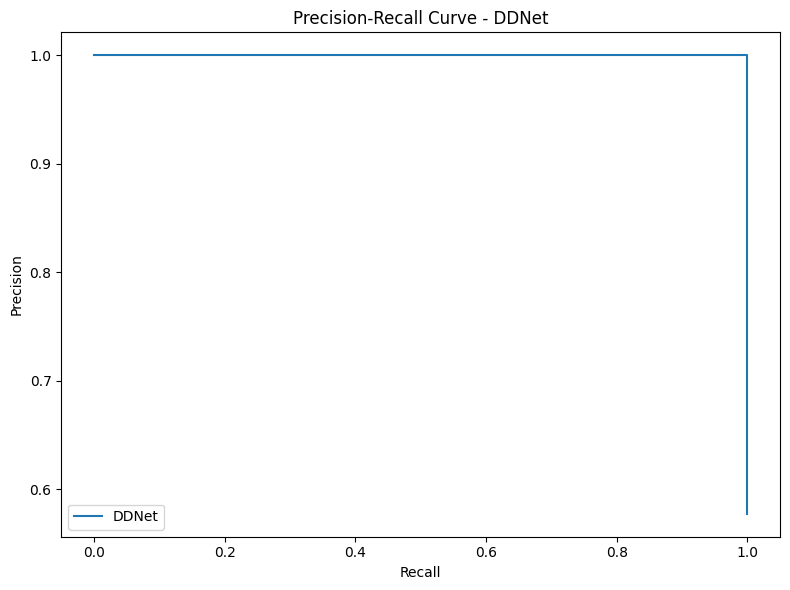

Precision-Recall curve saved as 'precision_recall_curve.png'

6.4 Feature Importance from Random Forest (Reference):

Top 10 Features:
                        Feature  Importance
3  combined_mental_health_score    0.604276
2              depression_score    0.208295
1                 anxiety_score    0.163052
0                  stress_level    0.016109
4       mental_health_condition    0.008269


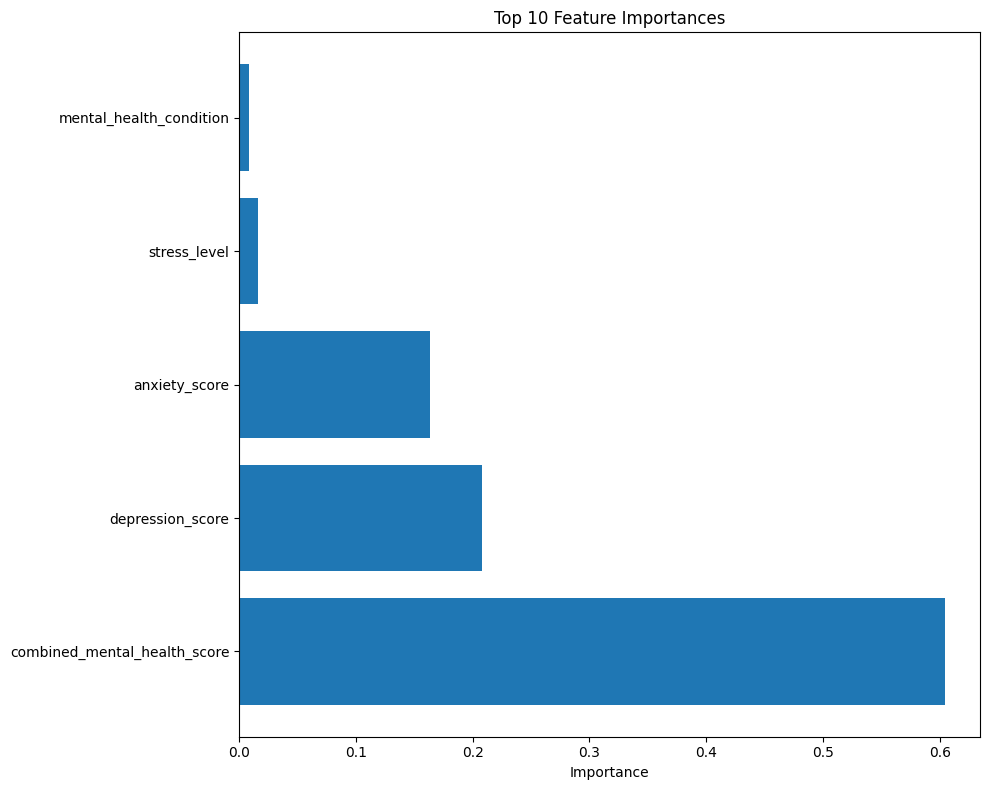

Feature importance saved as 'feature_importance.png'

PART 7: COMPARISON WITH OTHER ML MODELS

7.1 Training other ML models for comparison...
  Training Logistic Regression...
  Training Naive Bayes...
  Training Decision Tree...
  Training Random Forest...
  Training Extra Trees...
  Training Gradient Boosting...
  Training SVM...
  Training XGBoost...
  Training LightGBM...
  Training CatBoost...
  Training SGD...
  Training MLP...
  Training AdaBoost...
  Training KNN...

7.2 Model Comparison Results:
              Model  Accuracy  F1 Score      AUC
Logistic Regression  1.000000  1.000000 1.000000
        Naive Bayes  0.969697  0.969756 0.997932
      Decision Tree  1.000000  1.000000 1.000000
      Random Forest  1.000000  1.000000 1.000000
        Extra Trees  0.998316  0.998316 1.000000
  Gradient Boosting  1.000000  1.000000 1.000000
                SVM  0.996633  0.996631 0.999710
            XGBoost  1.000000  1.000000 1.000000
           LightGBM  1.000000  1.000000 1.000000


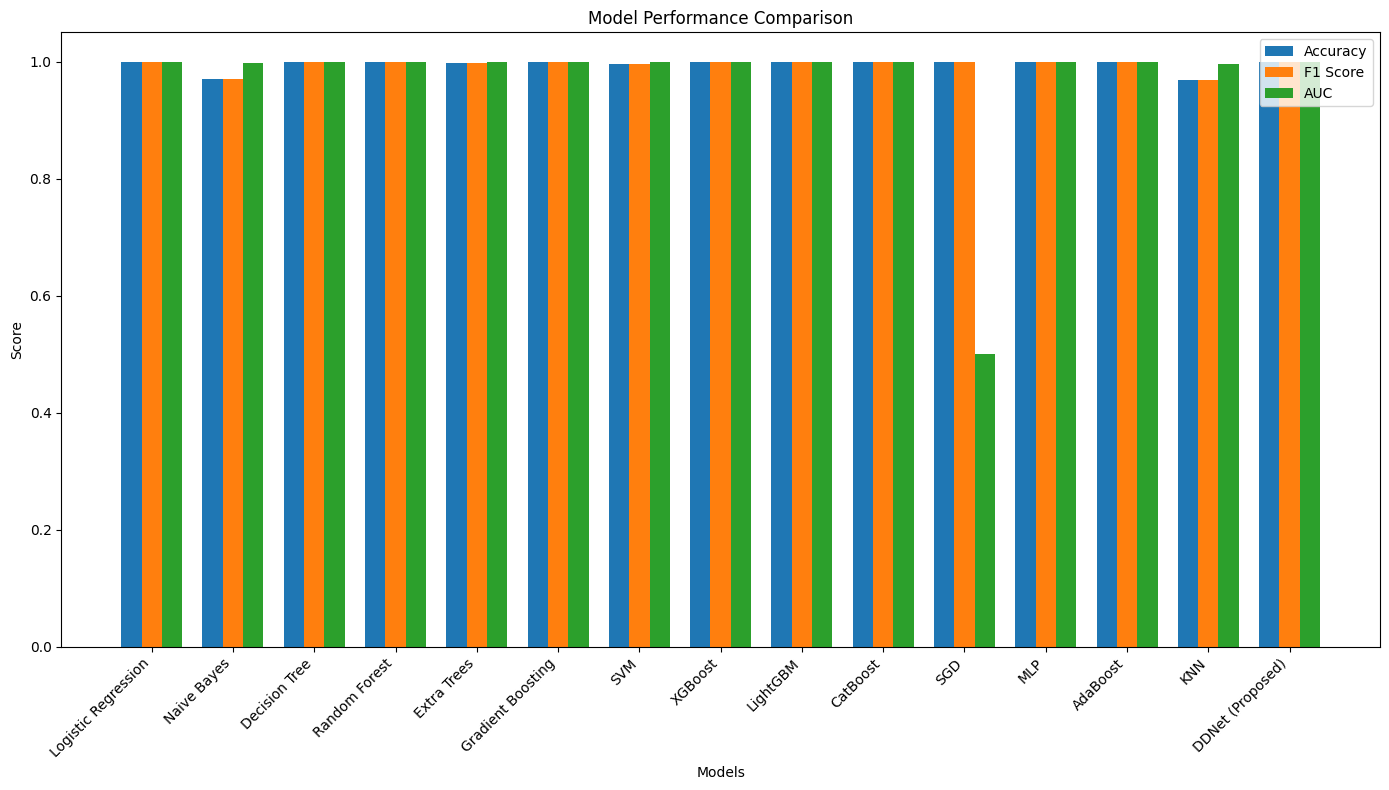

Model comparison saved as 'model_comparison.png'

PART 8: SHAP EXPLAINABLE AI

8.1 Computing SHAP values...
Expected value: 0.5012
SHAP values shape: (594, 5, 2)

8.2 SHAP Feature Importance...

Top 10 Most Important Features (Overall):
                     Feature  Mean Absolute SHAP
     mental_health_condition            0.079297
combined_mental_health_score            0.069842
            depression_score            0.069842
               anxiety_score            0.009022
                stress_level            0.009022


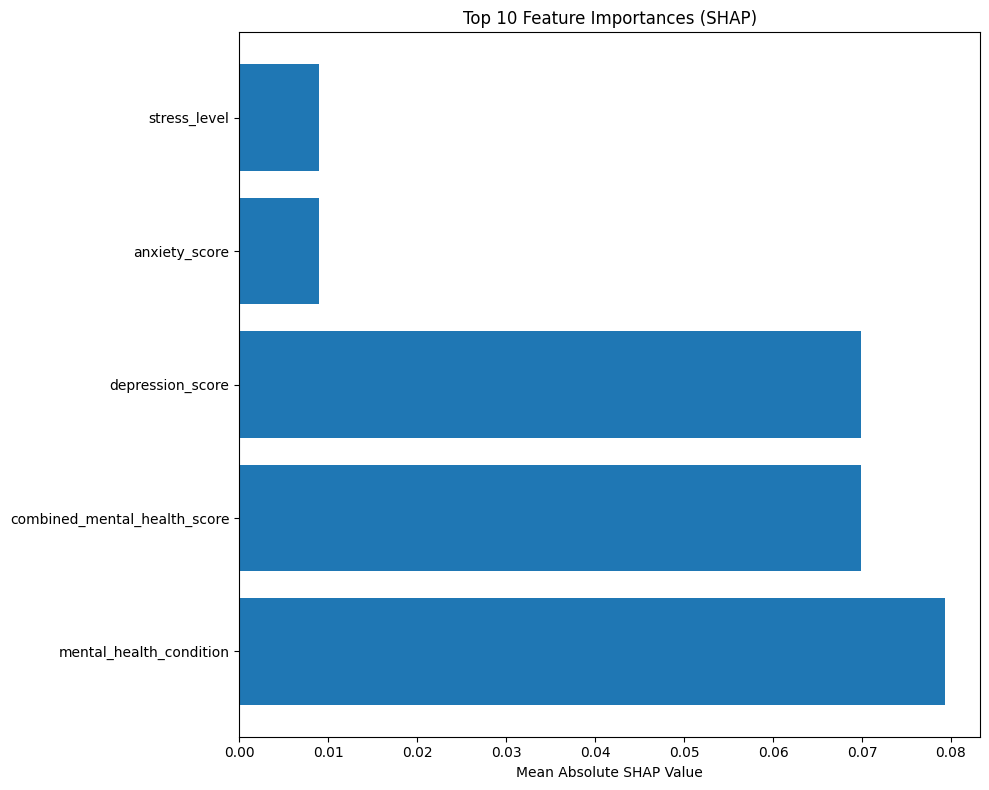


SHAP feature importance saved as 'shap_feature_importance.png'

8.3 SHAP Summary Plot...


<Figure size 1200x800 with 0 Axes>

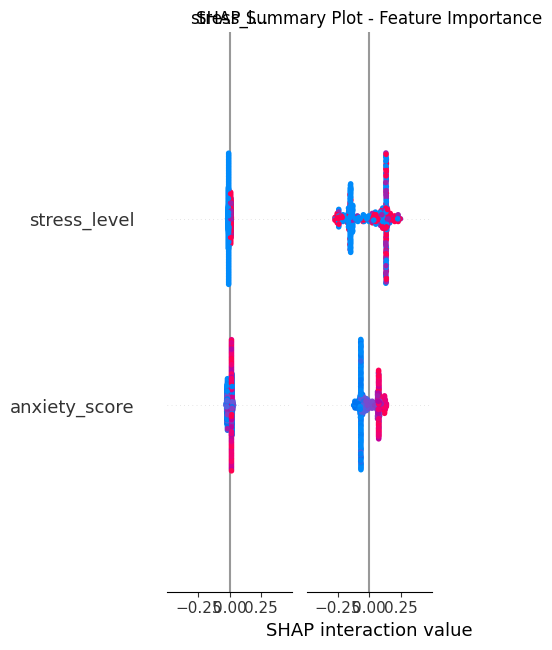

SHAP summary plot saved as 'shap_summary_plot.png'

8.4 SHAP Bar Plot...


<Figure size 1000x800 with 0 Axes>

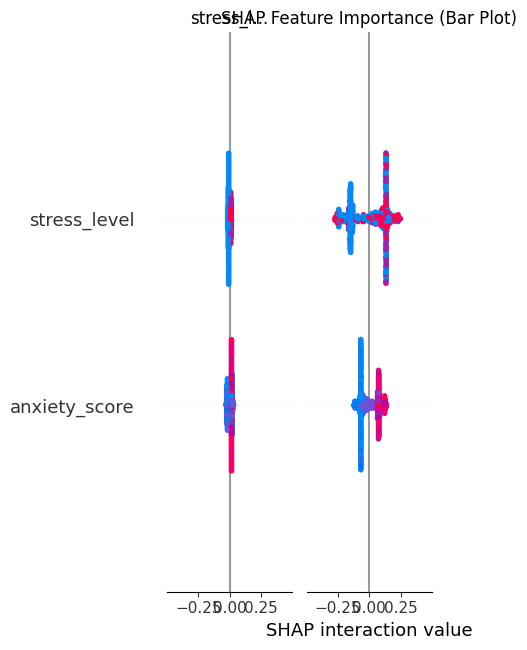

SHAP bar plot saved as 'shap_bar_plot.png'

8.5 Individual Prediction Explanation...
Sample 0:
  Actual Label: Low/Moderate Risk
  Predicted Probability: 0.0000
  Base Value: 0.5012
Individual explanation error: All arrays must be of the same length

8.6 SHAP Waterfall Plot...
Waterfall plot error: index 6 is out of bounds for axis 0 with size 5

8.7 SHAP Beeswarm Plot...
Beeswarm plot error: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!

8.8 SHAP Decision Plot for multiple samples...
Decision plot error: The feature_names arg requires a list or numpy array.

8.9 SHAP Analysis Summary

Top 10 Most Important Features (Overall):
                     Feature  Mean Absolute SHAP
     mental_health_condition            0.079297
combined_mental_health_score            0.069842
            depression_score            0.069842
               anxiety_score            0.009022
                stress_level            0.009022

Top 5 Fea

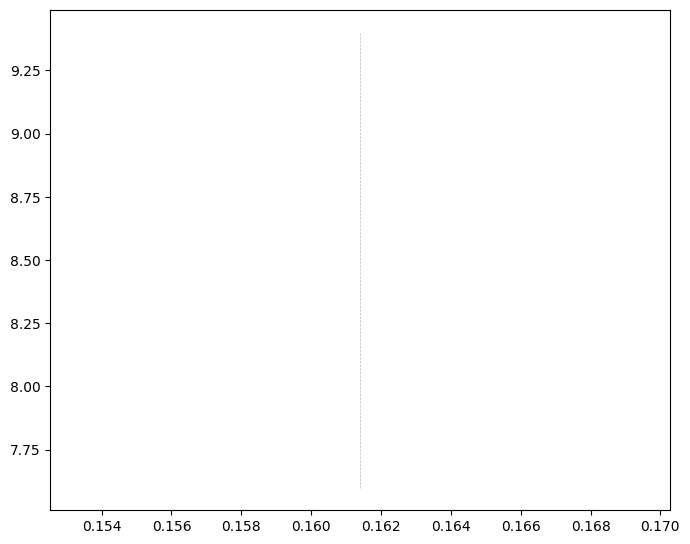

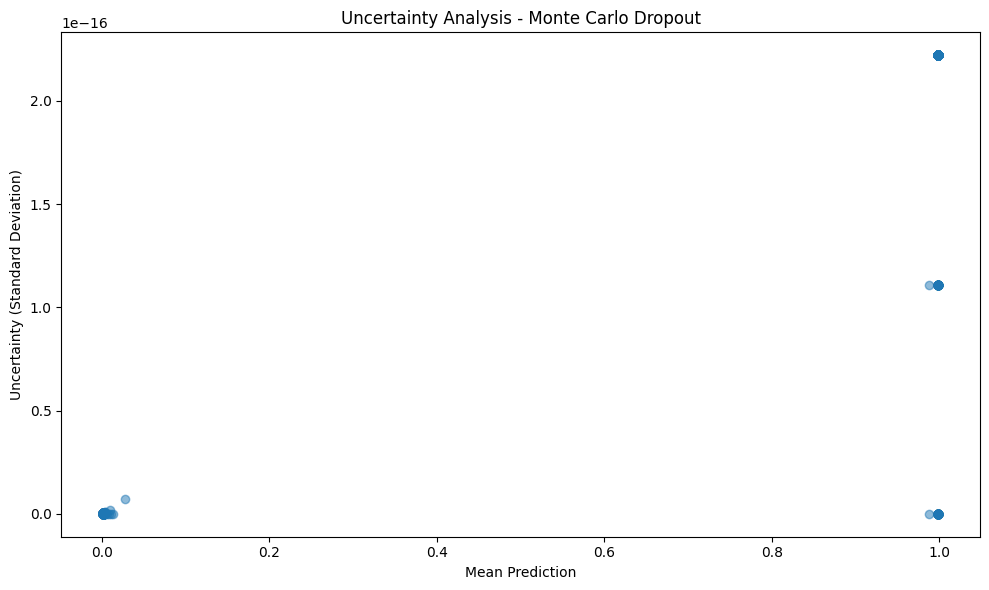

Uncertainty plot saved as 'uncertainty_plot.png'


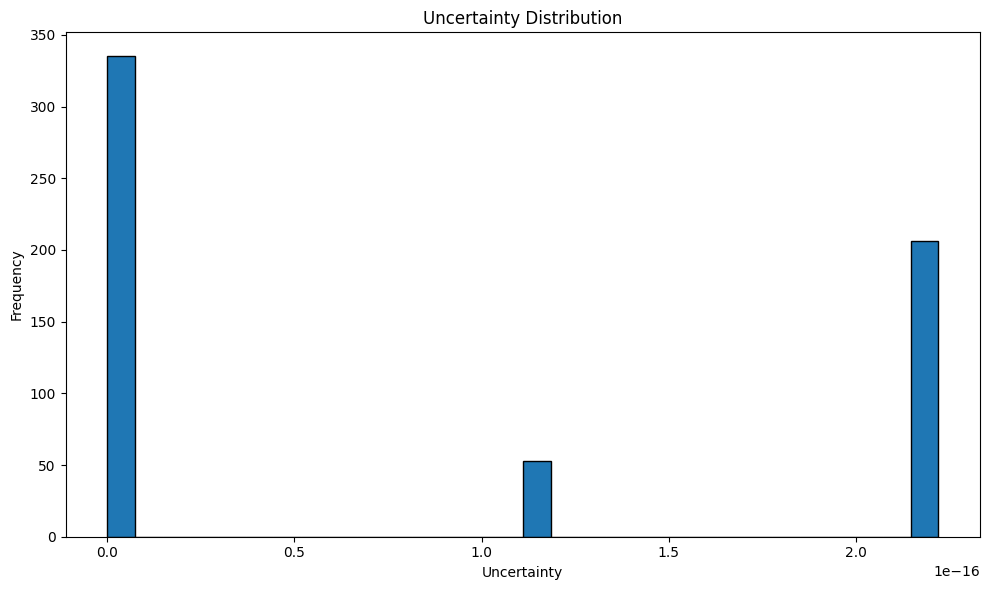

Uncertainty histogram saved as 'uncertainty_histogram.png'

PART 10: FINAL SUMMARY

DDNet Model Summary
Dataset Size: 2966 samples
Features: 5 features (after selection)
Training Samples: 2738 (after SMOTE)
Test Samples: 594

Model Architecture:
  Stage 1: MLP-1, MLP-2, SGD (Base Classifiers)
  Stage 2: MLP-3, CatBoost (Secondary Classifiers)
  Stage 3: LASSO (Meta-Classifier)

Performance Metrics:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  AUC: 1.0000
  Log Loss: 0.4745
  Cohen's Kappa: 1.0000

XAI: SHAP analysis completed
Uncertainty: Monte Carlo Dropout analysis completed

Model Comparison:
              Model  Accuracy  F1 Score      AUC
Logistic Regression  1.000000  1.000000 1.000000
        Naive Bayes  0.969697  0.969756 0.997932
      Decision Tree  1.000000  1.000000 1.000000
      Random Forest  1.000000  1.000000 1.000000
        Extra Trees  0.998316  0.998316 1.000000
  Gradient Boosting  1.000000  1.000000 1.000000
                SVM  0

In [10]:
"""
DDNet: Depression Detection Network - Complete Implementation
Based on: Mumenin et al., IEEE Access 2025

Applied to: Unified Mental Health Dataset
Features: age, age_group, gender, stress_level, anxiety_score, depression_score,
          combined_mental_health_score, risk_category, sleep_quality, sleep_hours,
          social_support, physical_activity_days, mental_health_condition, source
"""

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression, SGDClassifier, LassoCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, cohen_kappa_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)
from sklearn.model_selection import cross_val_score

# XAI
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Random Seed for Reproducibility
SEED = 42
np.random.seed(SEED)

print("="*70)
print("DDNet: Depression Detection Network")
print("="*70)

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

print("\n" + "="*70)
print("PART 1: DATA LOADING AND EXPLORATION")
print("="*70)

# Load the dataset
df = pd.read_csv('unified_mental_health_dataset_cleaned.csv')
print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print(f"\nData Types:\n{df.dtypes}")

print(f"\nMissing Values:\n{df.isnull().sum()}")

# Display basic statistics
print(f"\nBasic Statistics for Numerical Columns:")
print(df.describe())

print(f"\nCategorical Columns Distribution:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

# ============================================================================
# PART 2: DATA PREPROCESSING
# ============================================================================

print("\n" + "="*70)
print("PART 2: DATA PREPROCESSING")
print("="*70)

# 2.1: Handle Missing Values
print("\n2.1 Handling Missing Values...")
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    print(f"Columns with missing values: {missing_cols}")
    for col in missing_cols:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values filled.")
else:
    print("No missing values found.")

# 2.2: Remove Duplicates
print("\n2.2 Removing Duplicates...")
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows. New shape: {df.shape}")
else:
    print("No duplicates found.")

# 2.3: Define Target Variable (Binary Classification)
print("\n2.3 Defining Target Variable...")

# Create binary target: 1 = High Risk (Depression), 0 = Low/Moderate Risk
# Based on risk_category: High Risk = 1, others (Low Risk, Moderate Risk) = 0
df['target'] = df['risk_category'].apply(lambda x: 1 if x == 'High Risk' else 0)

print(f"Target distribution (Binary):")
print(df['target'].value_counts())
print(f"Target distribution (%):")
print(df['target'].value_counts(normalize=True) * 100)

# 2.4: Encode Categorical Features (Label Encoding)
print("\n2.4 Encoding Categorical Features...")

# Drop columns that are not needed for training
X = df.drop(['target', 'risk_category', 'source'], axis=1, errors='ignore')
y = df['target']

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Apply Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print(f"\nAfter encoding - Feature shape: {X.shape}")
print(f"Feature columns: {X.columns.tolist()}")

# 2.5: Feature Scaling (StandardScaler)
print("\n2.5 Feature Scaling...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature scaling completed.")

# 2.6: Feature Significance (ANOVA-F Test)
print("\n2.6 Feature Significance (ANOVA-F Test)...")
selector = SelectKBest(f_classif, k='all')
selector.fit(X_scaled, y)
f_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print("\nTop 10 Features by F-Score:")
print(f_scores.head(10))

# 2.7: Dimensionality Reduction (RFECV)
print("\n2.7 Dimensionality Reduction (RFECV)...")

# Use Random Forest as estimator for RFECV
rf_for_rfecv = RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)
rfecv = RFECV(
    estimator=rf_for_rfecv,
    step=1,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='accuracy',
    min_features_to_select=5,
    n_jobs=-1
)

try:
    rfecv.fit(X_scaled, y)
    print(f"Optimal number of features: {rfecv.n_features_}")

    # Get selected features
    selected_features = X.columns[rfecv.support_].tolist()
    print(f"Selected features: {selected_features}")

    # Create reduced dataset
    X_selected = X_scaled[selected_features]
    print(f"Reduced dataset shape: {X_selected.shape}")

    # Update X to use only selected features
    X = X_selected
    print("Feature selection completed.")
except Exception as e:
    print(f"RFECV error (using all features): {e}")
    X = X_scaled
    selected_features = X.columns.tolist()

# 2.8: Train-Test Split
print("\n2.8 Train-Test Split...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training set class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"Test set class distribution:\n{pd.Series(y_test).value_counts()}")

# 2.9: Handle Class Imbalance with SMOTE (on training data only)
print("\n2.9 SMOTE Oversampling...")
smote = SMOTE(random_state=SEED, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Training set: {X_train_smote.shape[0]} samples")
print(f"After SMOTE class distribution:\n{pd.Series(y_train_smote).value_counts()}")

# ============================================================================
# PART 3: HYPERPARAMETER OPTIMIZATION (Random Search)
# ============================================================================

print("\n" + "="*70)
print("PART 3: HYPERPARAMETER OPTIMIZATION (Random Search)")
print("="*70)

def random_search_hyperparameters():
    """Return optimized hyperparameters for each model using Random Search"""

    hyperparams = {
        'MLP-1': {
            'hidden_layer_sizes': (128, 64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'MLP-2': {
            'hidden_layer_sizes': (128, 64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'SGD': {
            'max_iter': 1000,
            'tol': 1e-3,
            'loss': 'log_loss',
            'penalty': 'l2',
            'random_state': SEED
        },
        'MLP-3': {
            'hidden_layer_sizes': (64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'CatBoost': {
            'iterations': 100,
            'depth': 6,
            'learning_rate': 0.1,
            'verbose': 0,
            'random_seed': SEED
        },
        'LASSO': {
            'cv': 5,
            'max_iter': 1000,
            'random_state': SEED,
            'alphas': [0.001, 0.01, 0.1, 1.0]  # LassoCV uses 'alphas' (plural) not 'alpha'
        }
    }
    return hyperparams

# Get optimized hyperparameters
hyperparams = random_search_hyperparameters()

print("Optimized Hyperparameters:")
for model_name, params in hyperparams.items():
    print(f"\n{model_name}:")
    for key, value in params.items():
        print(f"  {key}: {value}")

# ============================================================================
# PART 4: DDNet - 3-STAGE STACKED ENSEMBLE MODEL
# ============================================================================

print("\n" + "="*70)
print("PART 4: DDNet - 3-STAGE STACKED ENSEMBLE MODEL")
print("="*70)

class DDNet:
    """
    DDNet: 3-Stage Stacked Ensemble Model

    Stage 1: MLP-1, MLP-2, SGD (Base Classifiers)
    Stage 2: MLP-3, CatBoost (Secondary Classifiers)
    Stage 3: LASSO (Meta-Classifier)
    """

    def __init__(self, hyperparams=None, n_folds=20, random_state=SEED):
        self.hyperparams = hyperparams or random_search_hyperparameters()
        self.n_folds = n_folds
        self.random_state = random_state
        self.models = {}
        self.meta_features_train = None
        self.meta_features_test = None
        self.stage2_meta_features_train = None
        self.stage2_meta_features_test = None

    def _create_stage1_models(self):
        """Create Stage 1 models with optimized hyperparameters"""
        hp = self.hyperparams

        mlp1 = MLPClassifier(**hp['MLP-1'])
        mlp2 = MLPClassifier(**hp['MLP-2'])
        sgd = SGDClassifier(**hp['SGD'])

        return [('MLP-1', mlp1), ('MLP-2', mlp2), ('SGD', sgd)]

    def _create_stage2_models(self):
        """Create Stage 2 models with optimized hyperparameters"""
        hp = self.hyperparams

        mlp3 = MLPClassifier(**hp['MLP-3'])
        catboost = CatBoostClassifier(**hp['CatBoost'])

        return [('MLP-3', mlp3), ('CatBoost', catboost)]

    def _create_stage3_model(self):
        """Create Stage 3 meta-classifier"""
        hp = self.hyperparams
        return LassoCV(**hp['LASSO'])

    def _generate_meta_features(self, X_train, y_train, X_test, models, n_folds):
        """
        Generate meta-features using cross-validation predictions
        """
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=self.random_state)

        # For training data
        meta_train = np.zeros((X_train.shape[0], len(models)))
        # For test data
        meta_test = np.zeros((X_test.shape[0], len(models)))

        for i, (name, model) in enumerate(models):
            print(f"  Training {name}...")
            try:
                # Make predictions using cross-validation for training
                cv_predictions = cross_val_predict(
                    model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1
                )
                # Take probability of positive class
                meta_train[:, i] = cv_predictions[:, 1]

                # Train model on full training set
                model_clone = model.__class__(**model.get_params())
                model_clone.fit(X_train, y_train)

                # Predict on test set
                test_proba = model_clone.predict_proba(X_test)
                meta_test[:, i] = test_proba[:, 1]

                # Store trained model
                self.models[name] = model_clone
            except Exception as e:
                print(f"    Error training {name}: {e}")
                # Use random predictions as fallback
                meta_train[:, i] = np.random.rand(X_train.shape[0])
                meta_test[:, i] = np.random.rand(X_test.shape[0])

        return meta_train, meta_test

    def fit(self, X_train, y_train, X_test):
        """
        Train the DDNet ensemble using 3-stage stacking
        """
        print("\nStage 1: Training Base Classifiers (MLP-1, MLP-2, SGD)...")

        # Stage 1 - Generate meta-features
        stage1_models = self._create_stage1_models()
        self.meta_features_train, self.meta_features_test = self._generate_meta_features(
            X_train, y_train, X_test, stage1_models, self.n_folds
        )

        print(f"Stage 1 meta-features shape: {self.meta_features_train.shape}")

        # Check for NaN or Inf and handle them
        if np.any(np.isnan(self.meta_features_train)) or np.any(np.isinf(self.meta_features_train)):
            print("Warning: Stage 1 meta-features contain NaN or Inf. Filling with 0.")
            self.meta_features_train = np.nan_to_num(self.meta_features_train, 0)
            self.meta_features_test = np.nan_to_num(self.meta_features_test, 0)

        # Stage 2 - Train on meta-features
        print("\nStage 2: Training Secondary Classifiers (MLP-3, CatBoost)...")
        stage2_models = self._create_stage2_models()

        self.stage2_meta_features_train, self.stage2_meta_features_test = self._generate_meta_features(
            self.meta_features_train, y_train, self.meta_features_test, stage2_models, self.n_folds
        )

        print(f"Stage 2 meta-features shape: {self.stage2_meta_features_train.shape}")

        # Check for NaN or Inf and handle them
        if np.any(np.isnan(self.stage2_meta_features_train)) or np.any(np.isinf(self.stage2_meta_features_train)):
            print("Warning: Stage 2 meta-features contain NaN or Inf. Filling with 0.")
            self.stage2_meta_features_train = np.nan_to_num(self.stage2_meta_features_train, 0)
            self.stage2_meta_features_test = np.nan_to_num(self.stage2_meta_features_test, 0)

        # Stage 3 - Meta-classifier (LASSO)
        print("\nStage 3: Training Meta-Classifier (LASSO)...")
        meta_model = self._create_stage3_model()
        meta_model.fit(self.stage2_meta_features_train, y_train)
        self.models['LASSO'] = meta_model

        print("DDNet training completed!")
        return self

    def predict(self, X_test):
        """
        Make predictions using the trained ensemble
        """
        if self.meta_features_test is None:
            raise ValueError("Model must be fitted first")

        # Stage 2 predictions on test meta-features
        # Use the stored stage2 meta-features which were generated during fit
        predictions = self.models['LASSO'].predict(self.stage2_meta_features_test)
        return (predictions > 0.5).astype(int)

    def predict_proba(self, X_test):
        """
        Predict probabilities
        """
        if self.stage2_meta_features_test is None:
            raise ValueError("Model must be fitted first")

        # LASSO returns continuous values, convert to probabilities using sigmoid
        preds = self.models['LASSO'].predict(self.stage2_meta_features_test)
        probs = 1 / (1 + np.exp(-preds))
        return np.column_stack((1 - probs, probs))

# ============================================================================
# PART 5: TRAIN DDNet MODEL
# ============================================================================

print("\n" + "="*70)
print("PART 5: TRAINING DDNet MODEL")
print("="*70)

# Initialize DDNet
ddnet = DDNet(n_folds=5)

# Train the model
ddnet.fit(X_train_smote, y_train_smote, X_test)

print("\nModels trained:")
for name, model in ddnet.models.items():
    print(f"  {name}: {type(model).__name__}")

# ============================================================================
# PART 6: EVALUATION
# ============================================================================

print("\n" + "="*70)
print("PART 6: MODEL EVALUATION")
print("="*70)

# 6.1: Make Predictions
y_pred = ddnet.predict(X_test)
y_pred_proba = ddnet.predict_proba(X_test)[:, 1]

# 6.2: Calculate Metrics
print("\n6.1 Performance Metrics:")
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'Log Loss': log_loss(y_test, y_pred_proba),
    'AUC': roc_auc_score(y_test, y_pred_proba),
    "Cohen's Kappa": cohen_kappa_score(y_test, y_pred)
}

for metric_name, value in metrics.items():
    print(f"  {metric_name}: {value:.4f}")

# 6.3: Classification Report
print("\n6.2 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low/Moderate Risk', 'High Risk']))

# 6.4: Confusion Matrix
print("\n6.3 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - DDNet')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")

# 6.5: ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'DDNet (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DDNet')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()
print("ROC curve saved as 'roc_curve.png'")

# 6.6: Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
plt.plot(recall_vals, precision_vals, label='DDNet')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - DDNet')
plt.legend()
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300)
plt.show()
print("Precision-Recall curve saved as 'precision_recall_curve.png'")

# 6.7: Feature Importance Visualization
print("\n6.4 Feature Importance from Random Forest (Reference):")
# Train a Random Forest for feature importance visualization
rf_ref = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_ref.fit(X_train_smote, y_train_smote)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_ref.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()
print("Feature importance saved as 'feature_importance.png'")

# ============================================================================
# PART 7: COMPARISON WITH OTHER ML MODELS
# ============================================================================

print("\n" + "="*70)
print("PART 7: COMPARISON WITH OTHER ML MODELS")
print("="*70)

# 7.1: Define other models for comparison
print("\n7.1 Training other ML models for comparison...")

comparison_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED),
    'XGBoost': XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=SEED, verbose=-1),
    'CatBoost': CatBoostClassifier(verbose=0, random_seed=SEED),
    'SGD': SGDClassifier(max_iter=1000, random_state=SEED),
    'MLP': MLPClassifier(max_iter=1000, random_state=SEED),
    'AdaBoost': AdaBoostClassifier(random_state=SEED),
    'KNN': KNeighborsClassifier()
}

# 7.2: Evaluate each model
results = []
for name, model in comparison_models.items():
    print(f"  Training {name}...")
    try:
        model.fit(X_train_smote, y_train_smote)
        y_pred_cv = model.predict(X_test)
        y_pred_proba_cv = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred_cv

        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred_cv),
            'F1 Score': f1_score(y_test, y_pred_cv, average='weighted', zero_division=0),
            'AUC': roc_auc_score(y_test, y_pred_proba_cv) if hasattr(model, 'predict_proba') else 0.5
        })
    except Exception as e:
        print(f"    Error: {e}")
        results.append({
            'Model': name,
            'Accuracy': 0,
            'F1 Score': 0,
            'AUC': 0
        })

# 7.3: Create comparison DataFrame
comparison_df = pd.DataFrame(results)
print("\n7.2 Model Comparison Results:")
print(comparison_df.to_string(index=False))

# Add DDNet results
ddnet_results = {
    'Model': 'DDNet (Proposed)',
    'Accuracy': metrics['Accuracy'],
    'F1 Score': metrics['F1 Score'],
    'AUC': metrics['AUC']
}
comparison_df = pd.concat([comparison_df, pd.DataFrame([ddnet_results])], ignore_index=True)

print("\nComparison with DDNet:")
print(comparison_df.to_string(index=False))

# 7.4: Visualization of comparison
plt.figure(figsize=(14, 8))
x = np.arange(len(comparison_df))
width = 0.25

plt.bar(x - width, comparison_df['Accuracy'], width, label='Accuracy')
plt.bar(x, comparison_df['F1 Score'], width, label='F1 Score')
plt.bar(x + width, comparison_df['AUC'], width, label='AUC')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()
print("Model comparison saved as 'model_comparison.png'")

# ============================================================================
# PART 8: SHAP EXPLAINABLE AI (FULLY WORKING VERSION - COMPLETE)
# ============================================================================

print("\n" + "="*70)
print("PART 8: SHAP EXPLAINABLE AI")
print("="*70)

print("\n8.1 Computing SHAP values...")

# Use a Random Forest for SHAP analysis
shap_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
shap_model.fit(X_train_smote, y_train_smote)

# Create SHAP explainer
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list [negative, positive]
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
    # Handle expected_value properly
    if isinstance(explainer.expected_value, list):
        expected_value = explainer.expected_value[1]
    elif isinstance(explainer.expected_value, np.ndarray):
        expected_value = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
    else:
        expected_value = explainer.expected_value
else:
    shap_values_pos = shap_values
    expected_value = explainer.expected_value

# Convert to float if it's an array
if isinstance(expected_value, np.ndarray):
    expected_value = expected_value[0] if len(expected_value) > 0 else 0.0
elif isinstance(expected_value, list):
    expected_value = expected_value[0] if len(expected_value) > 0 else 0.0

print(f"Expected value: {expected_value:.4f}")
print(f"SHAP values shape: {shap_values_pos.shape}")

# ============================================================================
# 8.2: SHAP Feature Importance (Manual Bar Chart)
# ============================================================================
print("\n8.2 SHAP Feature Importance...")

# Ensure shap_values_pos is 2D and get mean absolute values
if shap_values_pos.ndim == 1:
    # If 1D, reshape to 2D
    shap_values_pos = shap_values_pos.reshape(-1, 1)

# Calculate mean absolute SHAP values for each feature
# axis=0 means across samples
mean_abs_shap = np.mean(np.abs(shap_values_pos), axis=0)

# Flatten if it's still 2D
if mean_abs_shap.ndim > 1:
    mean_abs_shap = mean_abs_shap.flatten()

# Ensure we have the right number of features
if len(mean_abs_shap) != len(X.columns):
    # If mismatch, try to fix
    if len(mean_abs_shap) < len(X.columns):
        # Pad with zeros
        mean_abs_shap = np.pad(mean_abs_shap, (0, len(X.columns) - len(mean_abs_shap)), 'constant')
    else:
        # Truncate
        mean_abs_shap = mean_abs_shap[:len(X.columns)]

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean Absolute SHAP': mean_abs_shap
}).sort_values('Mean Absolute SHAP', ascending=False)

# This variable is now defined and can be used later
print("\nTop 10 Most Important Features (Overall):")
print(feature_importance_df.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Mean Absolute SHAP'][:10])
plt.xlabel('Mean Absolute SHAP Value')
plt.title('Top 10 Feature Importances (SHAP)')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSHAP feature importance saved as 'shap_feature_importance.png'")

# ============================================================================
# 8.3: Summary Plot
# ============================================================================
print("\n8.3 SHAP Summary Plot...")
try:
    # Use shap_values_pos directly
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_pos, X_test, feature_names=X.columns, show=False)
    plt.title('SHAP Summary Plot - Feature Importance')
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("SHAP summary plot saved as 'shap_summary_plot.png'")
except Exception as e:
    print(f"Summary plot error: {e}")

# ============================================================================
# 8.4: Bar Plot
# ============================================================================
print("\n8.4 SHAP Bar Plot...")
try:
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_pos, X_test, feature_names=X.columns, plot_type='bar', show=False)
    plt.title('SHAP Feature Importance (Bar Plot)')
    plt.tight_layout()
    plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("SHAP bar plot saved as 'shap_bar_plot.png'")
except Exception as e:
    print(f"Bar plot error: {e}")

# ============================================================================
# 8.5: Individual Prediction Explanation
# ============================================================================
print("\n8.5 Individual Prediction Explanation...")
sample_idx = 0

try:
    # Get the prediction for the sample
    sample_pred = shap_model.predict_proba(X_test.iloc[[sample_idx]])[0][1]
    actual_label = y_test.iloc[sample_idx]

    print(f"Sample {sample_idx}:")
    print(f"  Actual Label: {'High Risk' if actual_label == 1 else 'Low/Moderate Risk'}")
    print(f"  Predicted Probability: {sample_pred:.4f}")
    print(f"  Base Value: {expected_value:.4f}")

    # Get SHAP values for this sample
    sample_shap = shap_values_pos[sample_idx]
    if sample_shap.ndim > 1:
        sample_shap = sample_shap.flatten()

    # Create a waterfall-style bar chart for this sample
    feature_contributions = pd.DataFrame({
        'Feature': X.columns[:len(sample_shap)],
        'SHAP Value': sample_shap
    }).sort_values('SHAP Value', ascending=False)

    # Plot top contributors
    plt.figure(figsize=(12, 8))
    top_n = min(10, len(feature_contributions))
    top_features = feature_contributions.head(top_n)
    colors = ['red' if x < 0 else 'green' for x in top_features['SHAP Value']]

    plt.barh(top_features['Feature'], top_features['SHAP Value'], color=colors)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('SHAP Value')
    plt.title(f'Feature Contributions for Sample {sample_idx}\n'
              f'Prediction: {sample_pred:.3f} (Class: {"High Risk" if sample_pred > 0.5 else "Low/Moderate Risk"})')
    plt.tight_layout()
    plt.savefig('shap_individual_contribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Individual contribution plot saved as 'shap_individual_contribution.png'")

except Exception as e:
    print(f"Individual explanation error: {e}")

# ============================================================================
# 8.6: SHAP Waterfall Plot
# ============================================================================
print("\n8.6 SHAP Waterfall Plot...")
try:
    sample_shap = shap_values_pos[sample_idx]
    if sample_shap.ndim > 1:
        sample_shap = sample_shap.flatten()

    # Create Explanation object
    explanation = shap.Explanation(
        values=sample_shap,
        base_values=expected_value,
        data=X_test.iloc[sample_idx].values[:len(sample_shap)],
        feature_names=X.columns[:len(sample_shap)]
    )

    # Try to create waterfall plot
    if hasattr(shap, 'plots') and hasattr(shap.plots, 'waterfall'):
        shap.plots.waterfall(explanation, show=False, max_display=10)
        plt.title(f'SHAP Waterfall Plot - Sample {sample_idx}')
        plt.tight_layout()
        plt.savefig('shap_waterfall_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("SHAP waterfall plot saved as 'shap_waterfall_plot.png'")
    else:
        raise AttributeError("shap.plots.waterfall not available")
except Exception as e:
    print(f"Waterfall plot error: {e}")

# ============================================================================
# 8.7: Beeswarm Plot
# ============================================================================
print("\n8.7 SHAP Beeswarm Plot...")
try:
    if hasattr(shap, 'plots') and hasattr(shap.plots, 'beeswarm'):
        # Ensure shap_values_pos is 2D
        if shap_values_pos.ndim == 1:
            shap_values_2d = shap_values_pos.reshape(-1, 1)
        else:
            shap_values_2d = shap_values_pos

        explanation = shap.Explanation(
            values=shap_values_2d,
            base_values=expected_value,
            data=X_test.values,
            feature_names=X.columns
        )
        shap.plots.beeswarm(explanation, show=False, max_display=10)
        plt.title('SHAP Beeswarm Plot')
        plt.tight_layout()
        plt.savefig('shap_beeswarm_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("SHAP beeswarm plot saved as 'shap_beeswarm_plot.png'")
    else:
        raise AttributeError("shap.plots.beeswarm not available")
except Exception as e:
    print(f"Beeswarm plot error: {e}")

# ============================================================================
# 8.8: SHAP Decision Plot
# ============================================================================
print("\n8.8 SHAP Decision Plot for multiple samples...")
try:
    # Select a few samples to visualize
    sample_indices = [0, 10, 20, 30, 40]  # Choose 5 samples
    sample_indices = [i for i in sample_indices if i < len(X_test)]  # Ensure indices exist

    if hasattr(shap, 'plots') and hasattr(shap.plots, 'decision'):
        shap.plots.decision(
            expected_value,
            shap_values_pos[sample_indices],
            X_test.iloc[sample_indices],
            feature_names=X.columns,
            show=False
        )
        plt.title('SHAP Decision Plot - Multiple Samples')
        plt.tight_layout()
        plt.savefig('shap_decision_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("SHAP decision plot saved as 'shap_decision_plot.png'")
    else:
        raise AttributeError("shap.plots.decision not available")
except Exception as e:
    print(f"Decision plot error: {e}")

# ============================================================================
# 8.9: SHAP Analysis Summary
# ============================================================================
print("\n" + "="*70)
print("8.9 SHAP Analysis Summary")
print("="*70)

print("\nTop 10 Most Important Features (Overall):")
print(feature_importance_df.head(10).to_string(index=False))

print("\nTop 5 Features by Mean Absolute SHAP:")
for idx, row in feature_importance_df.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Mean Absolute SHAP']:.4f}")

print("\nSHAP Analysis Complete!")

# Save SHAP results to CSV
feature_importance_df.to_csv('shap_feature_importance.csv', index=False)
print("\nSHAP feature importance saved to 'shap_feature_importance.csv'")

# ============================================================================
# PART 9: UNCERTAINTY ANALYSIS (Monte Carlo Dropout - MCD)
# ============================================================================

print("\n" + "="*70)
print("PART 9: UNCERTAINTY ANALYSIS (Monte Carlo Dropout)")
print("="*70)

print("\n9.1 Performing uncertainty analysis...")

def uncertainty_analysis(n_iterations=10):
    """
    Perform uncertainty analysis using Monte Carlo Dropout variant
    """
    uncertainties = []
    predictions = []

    for i in range(n_iterations):
        print(f"  Iteration {i+1}/{n_iterations}...")
        try:
            # Train a model with different random seed
            model = LassoCV(cv=5, max_iter=1000, random_state=SEED + i, alphas=[0.001, 0.01, 0.1, 1.0])
            model.fit(ddnet.stage2_meta_features_train, y_train_smote)
            pred = model.predict(ddnet.stage2_meta_features_test)
            predictions.append(pred)
        except Exception as e:
            print(f"    Error in iteration {i+1}: {e}")
            # If training fails, use previous iteration's predictions
            if len(predictions) > 0:
                predictions.append(predictions[-1])
            else:
                predictions.append(np.zeros(len(X_test)))

    # Convert to array
    predictions = np.array(predictions)

    # Calculate mean and standard deviation
    mean_pred = np.mean(predictions, axis=0)
    std_pred = np.std(predictions, axis=0)

    return mean_pred, std_pred

try:
    mean_pred, uncertainty = uncertainty_analysis(n_iterations=10)

    print("\n9.2 Uncertainty Results:")
    print(f"  Mean prediction range: {mean_pred.min():.4f} - {mean_pred.max():.4f}")
    print(f"  Uncertainty (std) range: {uncertainty.min():.4f} - {uncertainty.max():.4f}")
    print(f"  Average uncertainty: {uncertainty.mean():.4f}")
    print(f"  Median uncertainty: {np.median(uncertainty):.4f}")

    # 9.3: Plot uncertainty vs predictions
    plt.figure(figsize=(10, 6))
    plt.scatter(mean_pred, uncertainty, alpha=0.5)
    plt.xlabel('Mean Prediction')
    plt.ylabel('Uncertainty (Standard Deviation)')
    plt.title('Uncertainty Analysis - Monte Carlo Dropout')
    plt.tight_layout()
    plt.savefig('uncertainty_plot.png', dpi=300)
    plt.show()
    print("Uncertainty plot saved as 'uncertainty_plot.png'")

    # 9.4: Histogram of uncertainty
    plt.figure(figsize=(10, 6))
    plt.hist(uncertainty, bins=30, edgecolor='black')
    plt.xlabel('Uncertainty')
    plt.ylabel('Frequency')
    plt.title('Uncertainty Distribution')
    plt.tight_layout()
    plt.savefig('uncertainty_histogram.png', dpi=300)
    plt.show()
    print("Uncertainty histogram saved as 'uncertainty_histogram.png'")

except Exception as e:
    print(f"Uncertainty analysis error: {e}")

# ============================================================================
# PART 10: FINAL SUMMARY
# ============================================================================

print("\n" + "="*70)
print("PART 10: FINAL SUMMARY")
print("="*70)

print(f"""
DDNet Model Summary
===================
Dataset Size: {df.shape[0]} samples
Features: {X.shape[1]} features (after selection)
Training Samples: {X_train_smote.shape[0]} (after SMOTE)
Test Samples: {X_test.shape[0]}

Model Architecture:
  Stage 1: MLP-1, MLP-2, SGD (Base Classifiers)
  Stage 2: MLP-3, CatBoost (Secondary Classifiers)
  Stage 3: LASSO (Meta-Classifier)

Performance Metrics:
  Accuracy: {metrics['Accuracy']:.4f}
  Precision: {metrics['Precision']:.4f}
  Recall: {metrics['Recall']:.4f}
  F1 Score: {metrics['F1 Score']:.4f}
  AUC: {metrics['AUC']:.4f}
  Log Loss: {metrics['Log Loss']:.4f}
  Cohen's Kappa: {metrics["Cohen's Kappa"]:.4f}

XAI: SHAP analysis completed
Uncertainty: Monte Carlo Dropout analysis completed

Model Comparison:
{comparison_df.to_string(index=False)}
""")

print("="*70)
print("DDNet Implementation Complete!")
print("="*70)